In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             roc_curve, precision_recall_curve,
                             ConfusionMatrixDisplay)
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

In [3]:
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
print("📁 Path to dataset files:", path)

csv_file = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(csv_file)

print(f"\n✅ Dataset Loaded!")
print(f"📐 Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
📁 Path to dataset files: /kaggle/input/telco-customer-churn

✅ Dataset Loaded!
📐 Shape: 7043 rows × 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("=" * 55)
print("📋 BASIC INFO")
print("=" * 55)
df.info()

print("\n" + "=" * 55)
print("📊 STATISTICAL SUMMARY")
print("=" * 55)
df.describe(include='all').T

📋 BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nu

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:

# ── 4.1 Drop irrelevant column
df.drop(columns=['customerID'], inplace=True)
print("'customerID' column dropped")

# ── 4.2 Fix TotalCharges (object → numeric)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f" 'TotalCharges' converted to numeric")

# ── 4.3 Missing values check
print("\n Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0])

# ── 4.4 Fill missing TotalCharges with median
median_tc = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_tc, inplace=True)
print(f"\n Missing 'TotalCharges' filled with median: {median_tc:.2f}")

# ── 4.5 Duplicate check
dups = df.duplicated().sum()
print(f"\n Duplicate rows: {dups}")
if dups > 0:
    df.drop_duplicates(inplace=True)
    print(" Duplicates removed!")
else:
    print(" No duplicates found!")

# ── 4.6 Strip whitespace from object columns
obj_cols = df.select_dtypes(include='object').columns
df[obj_cols] = df[obj_cols].apply(lambda x: x.str.strip())
print("\n Whitespace stripped from all string columns")

# ── 4.7 Fix binary columns → Yes/No consistency
print(f"\n Cleaned Shape: {df.shape}")
df.head(3)

'customerID' column dropped
 'TotalCharges' converted to numeric

 Missing Values:
TotalCharges    11
dtype: int64

 Missing 'TotalCharges' filled with median: 1397.47

 Duplicate rows: 22
 Duplicates removed!

 Whitespace stripped from all string columns

 Cleaned Shape: (7021, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


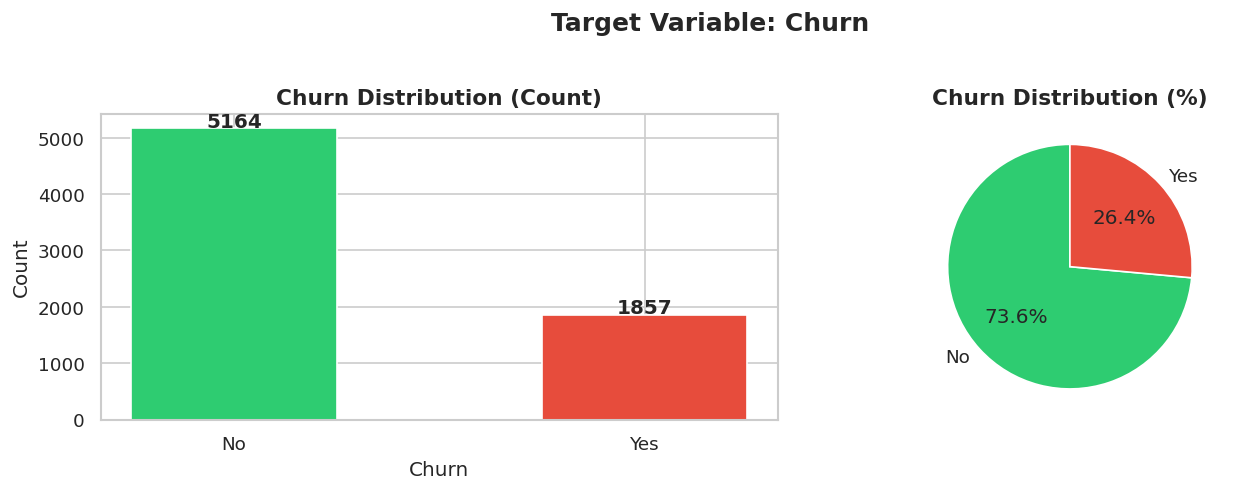

💾 Saved: 01_churn_distribution.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
churn_counts = df['Churn'].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Churn Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Churn Distribution (%)', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Churn', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_churn_distribution.png', bbox_inches='tight')
plt.show()
print("💾 Saved: 01_churn_distribution.png")

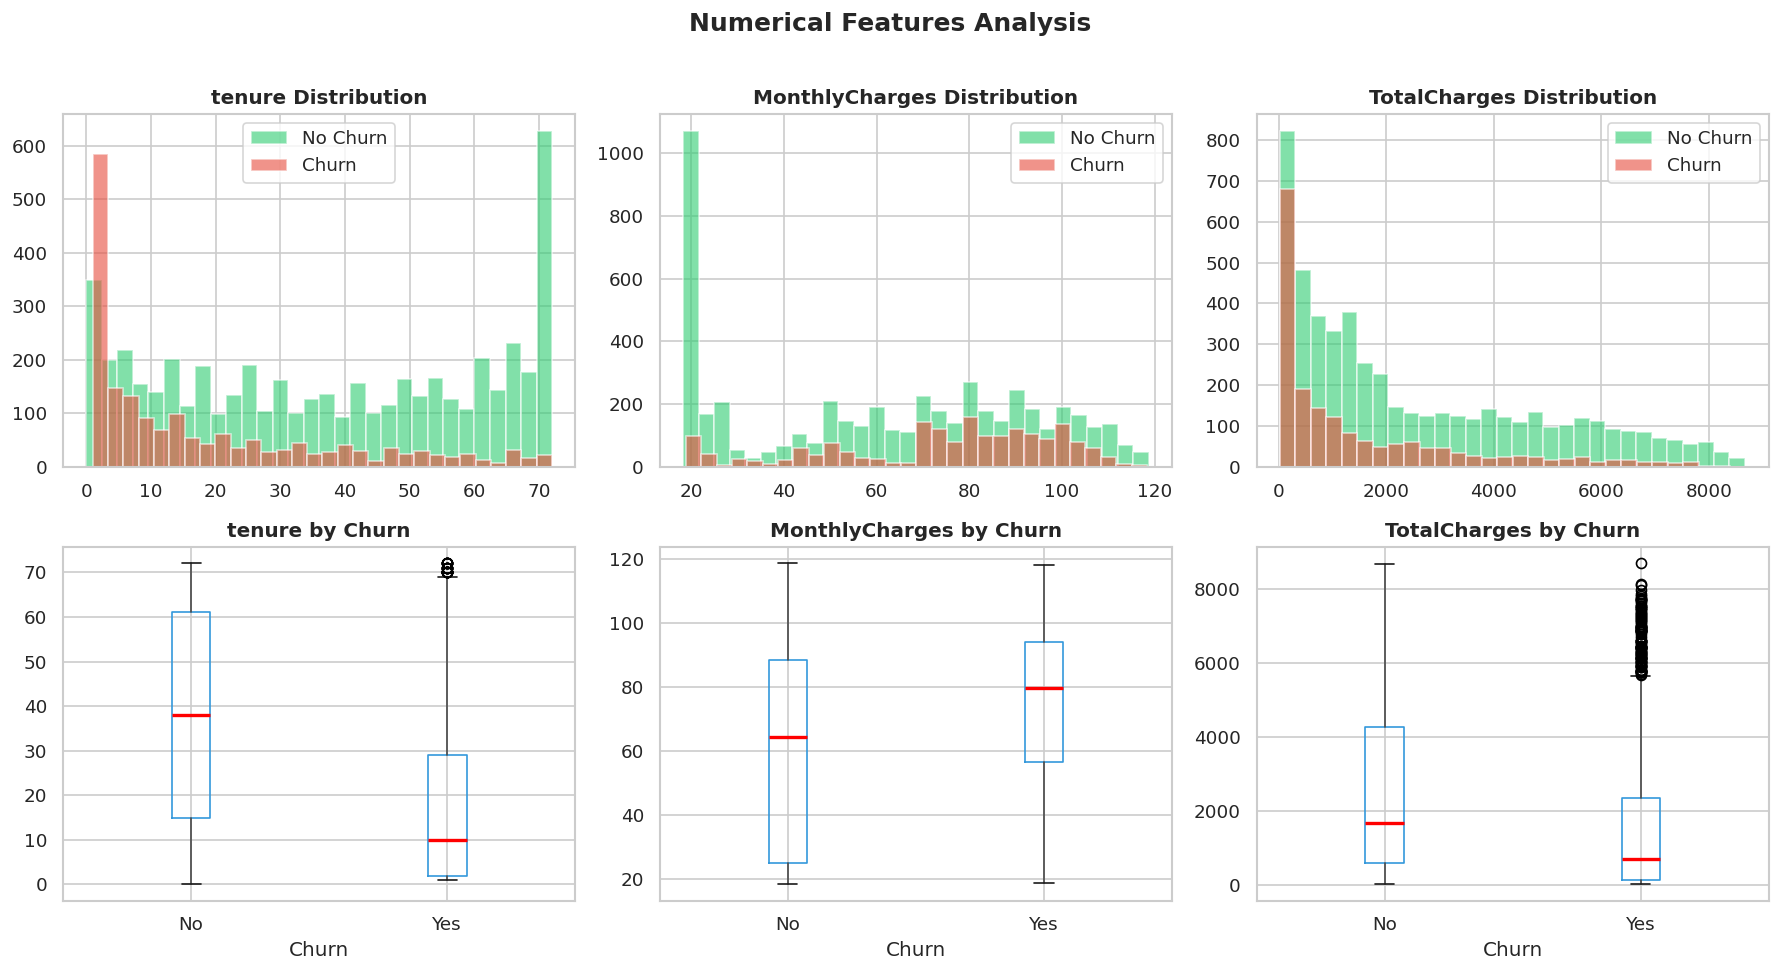

💾 Saved: 02_numerical_features.png


In [7]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for i, col in enumerate(num_cols):
    # Histogram
    axes[0, i].hist(df[df['Churn'] == 'No'][col],  bins=30,
                    alpha=0.6, color='#2ecc71', label='No Churn')
    axes[0, i].hist(df[df['Churn'] == 'Yes'][col], bins=30,
                    alpha=0.6, color='#e74c3c', label='Churn')
    axes[0, i].set_title(f'{col} Distribution', fontweight='bold')
    axes[0, i].legend()

    # Boxplot
    df.boxplot(column=col, by='Churn', ax=axes[1, i],
               boxprops=dict(color='#3498db'),
               medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f'{col} by Churn', fontweight='bold')
    axes[1, i].set_xlabel('Churn')

plt.suptitle('Numerical Features Analysis', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('02_numerical_features.png', bbox_inches='tight')
plt.show()
print("💾 Saved: 02_numerical_features.png")

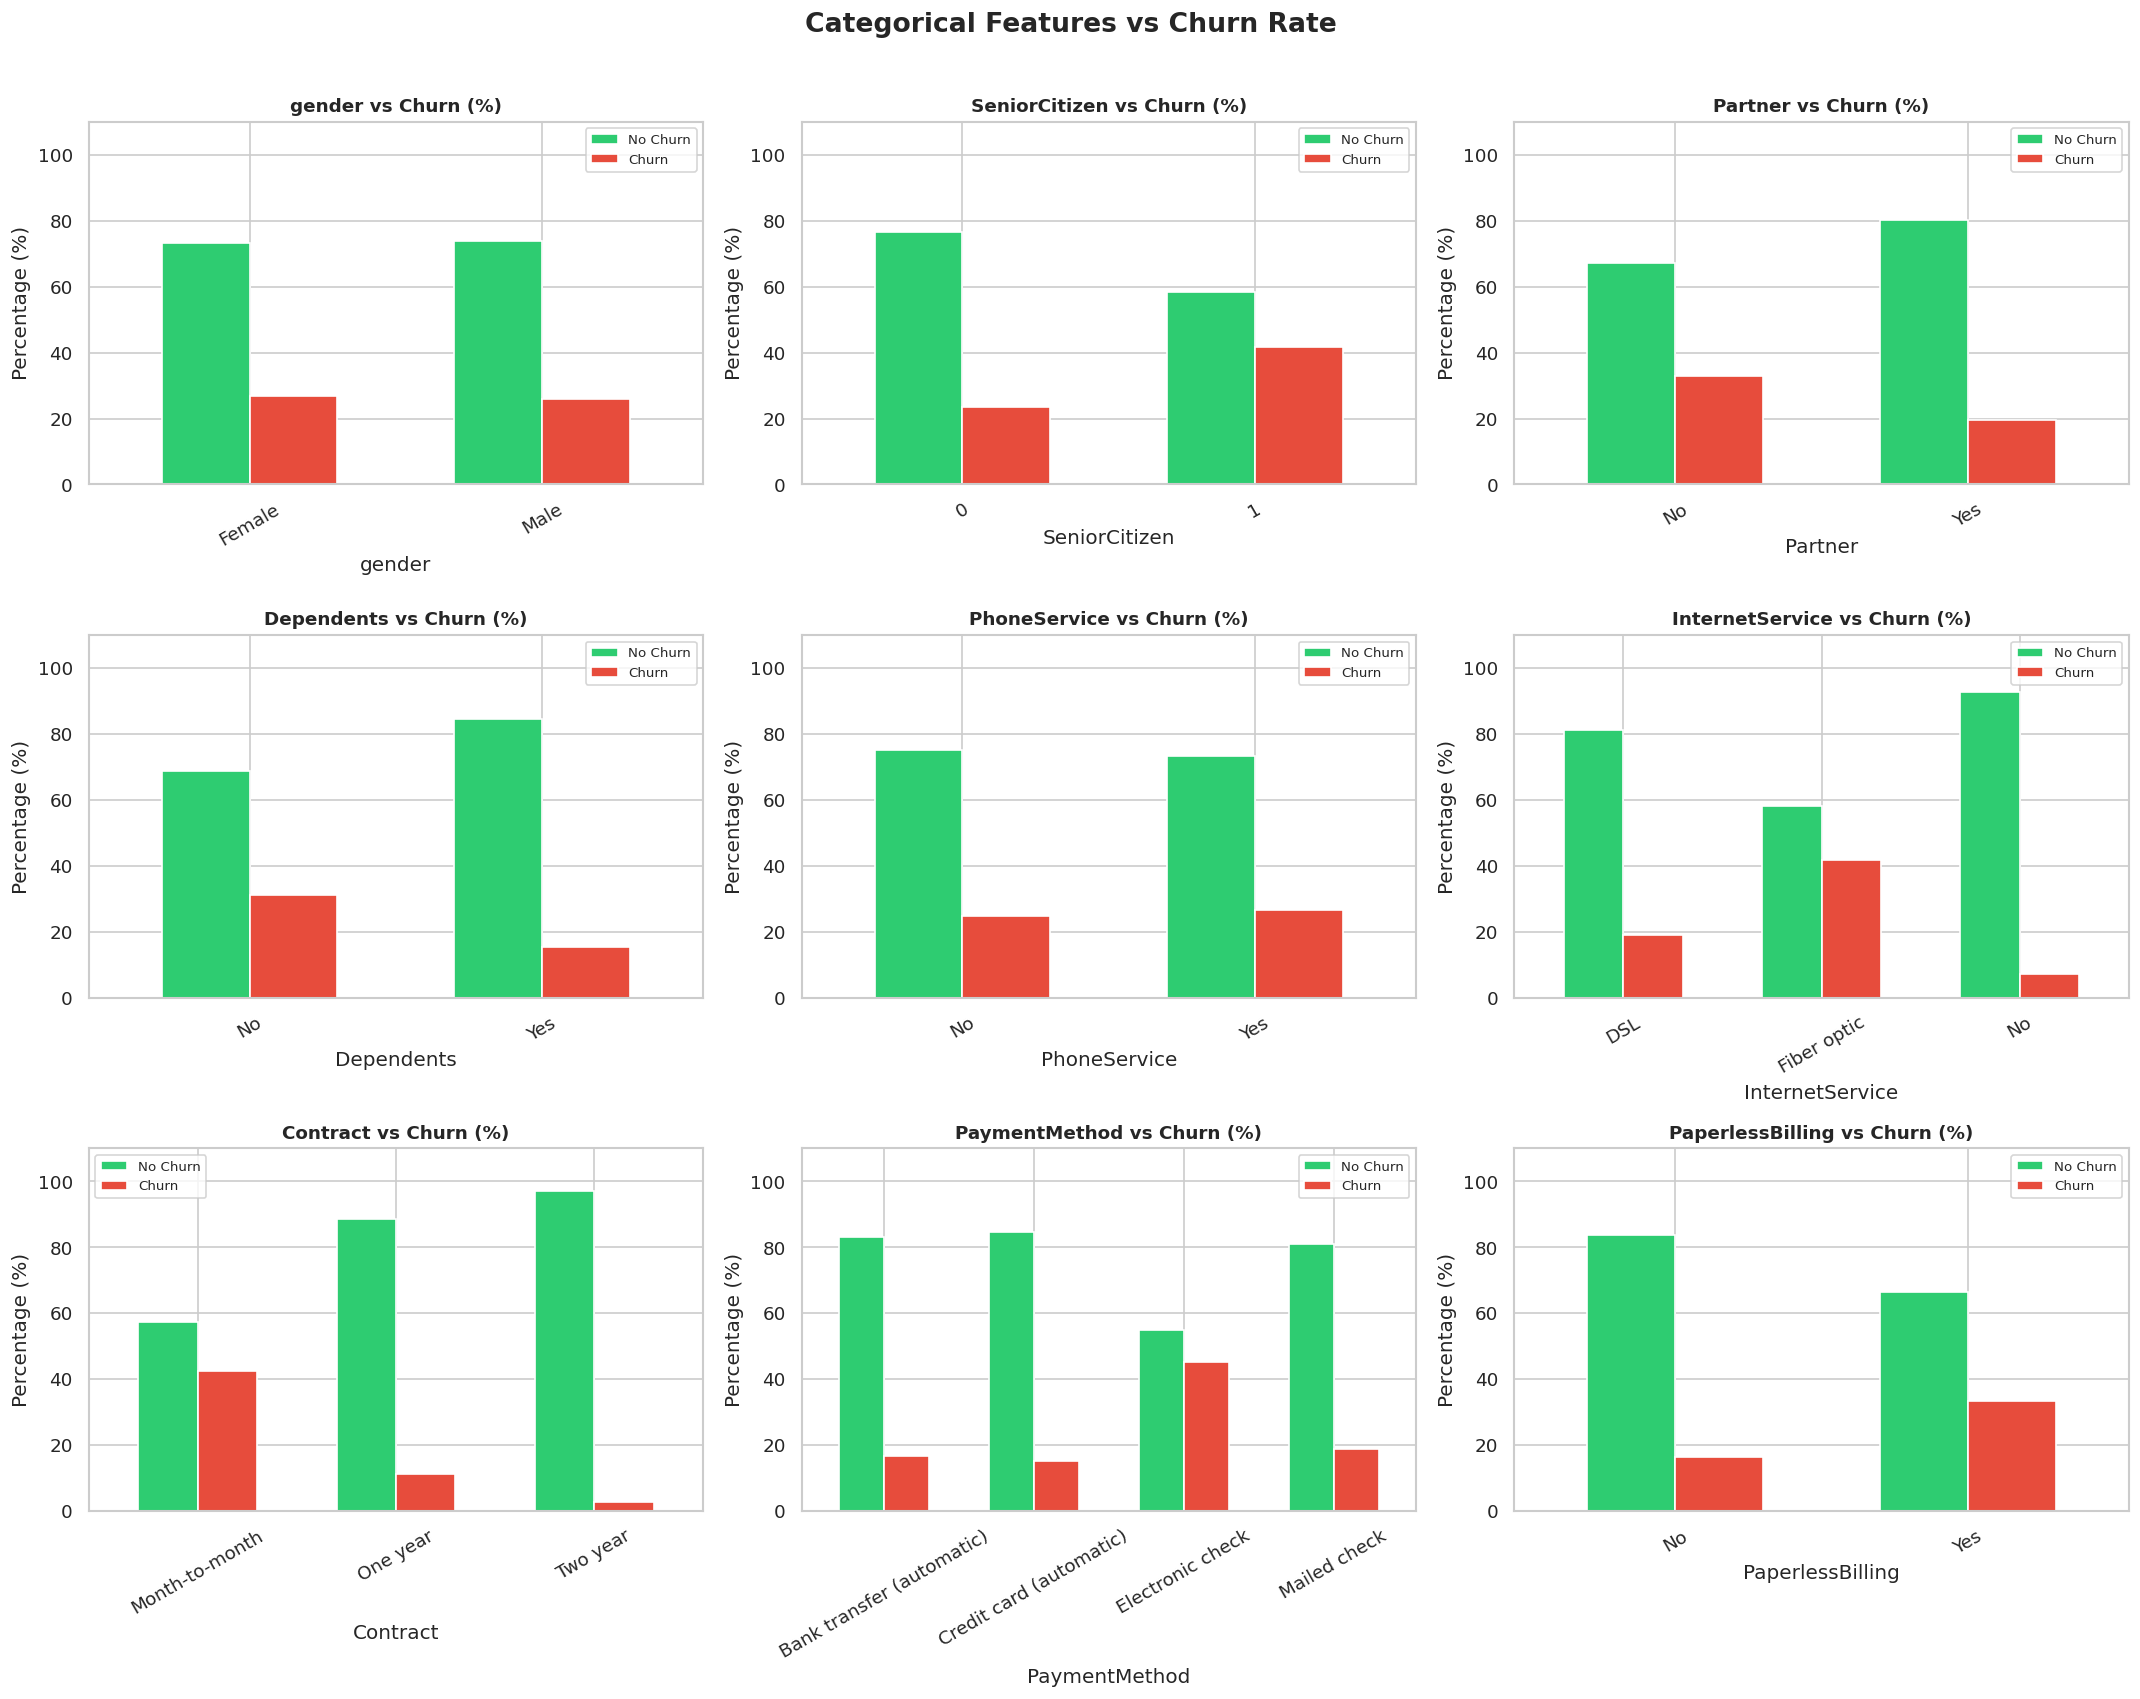

💾 Saved: 03_categorical_features.png


In [8]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'InternetService', 'Contract',
            'PaymentMethod', 'PaperlessBilling']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
            edgecolor='white', width=0.6)
    axes[i].set_title(f'{col} vs Churn (%)', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(['No Churn', 'Churn'], fontsize=8)
    axes[i].set_ylim(0, 110)

plt.suptitle('Categorical Features vs Churn Rate',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_categorical_features.png', bbox_inches='tight')
plt.show()
print("💾 Saved: 03_categorical_features.png")

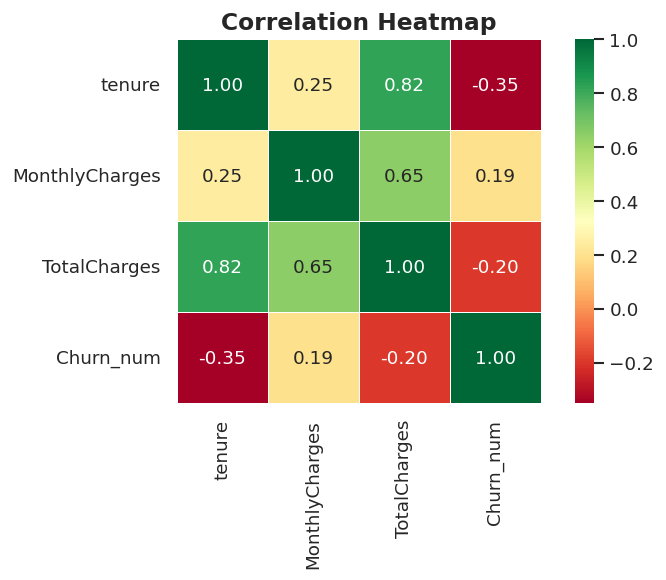

💾 Saved: 04_correlation_heatmap.png


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

corr_df = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
corr_df['Churn_num'] = (df['Churn'] == 'Yes').astype(int)

sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, ax=ax, square=True,
            annot_kws={'fontsize': 11})
ax.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print("💾 Saved: 04_correlation_heatmap.png")

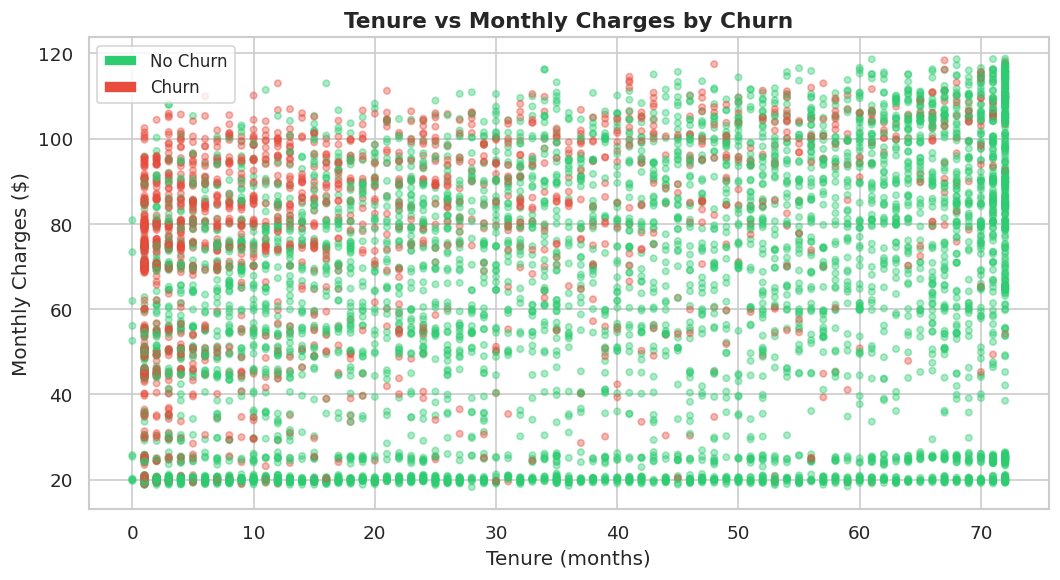

💾 Saved: 05_scatter_tenure_charges.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = df['Churn'].map({'No': '#2ecc71', 'Yes': '#e74c3c'})
scatter = ax.scatter(df['tenure'], df['MonthlyCharges'],
                     c=colors, alpha=0.4, s=15)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='No Churn'),
                   Patch(facecolor='#e74c3c', label='Churn')]
ax.legend(handles=legend_elements, fontsize=10)
ax.set_title('Tenure vs Monthly Charges by Churn',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig('05_scatter_tenure_charges.png', bbox_inches='tight')
plt.show()
print("💾 Saved: 05_scatter_tenure_charges.png")

In [11]:
df_model = df.copy()

# ── 6.1 Encode Target
df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})
print("✅ Target encoded → Yes:1 / No:0")

# ── 6.2 Binary columns → 0/1
binary_map = {'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0}
binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines']

for col in binary_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].map(binary_map)

df_model['SeniorCitizen'] = df_model['SeniorCitizen'].astype(int)
print("✅ Binary columns encoded")

# ── 6.3 Multi-class Categorical → One-Hot Encoding
multi_cat = ['InternetService', 'Contract', 'PaymentMethod',
             'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
             'TechSupport', 'StreamingTV', 'StreamingMovies']

# Keep only columns that exist
multi_cat = [c for c in multi_cat if c in df_model.columns]

df_model = pd.get_dummies(df_model, columns=multi_cat, drop_first=True)
print(f"✅ One-Hot Encoding applied to {len(multi_cat)} columns")

# ── 6.4 Handle any remaining nulls
df_model.fillna(df_model.median(numeric_only=True), inplace=True)

print(f"\n📐 Final Shape after encoding: {df_model.shape}")
print(f"\n🔢 Features: {df_model.shape[1] - 1}")
df_model.head(3)

✅ Target encoded → Yes:1 / No:0
✅ Binary columns encoded
✅ One-Hot Encoding applied to 9 columns

📐 Final Shape after encoding: (7021, 30)

🔢 Features: 29


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,PaperlessBilling,MonthlyCharges,TotalCharges,...,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,0,1,0,1,0,0.0,1,29.85,29.85,...,False,True,False,False,False,False,False,False,False,False
1,1,0,0,0,34,1,0.0,0,56.95,1889.50,...,False,False,False,True,False,False,False,False,False,False
2,1,0,0,0,2,1,0.0,1,53.85,108.15,...,False,True,False,False,False,False,False,False,False,False


In [12]:
# Services count
service_cols_raw = ['PhoneService', 'MultipleLines', 'OnlineSecurity_Yes',
                    'OnlineBackup_Yes', 'DeviceProtection_Yes',
                    'TechSupport_Yes', 'StreamingTV_Yes', 'StreamingMovies_Yes']

available = [c for c in service_cols_raw if c in df_model.columns]
df_model['total_services'] = df_model[available].sum(axis=1)
print("✅ 'total_services' feature created")

# Charges per month ratio
df_model['charges_per_tenure'] = (df_model['TotalCharges'] /
                                   (df_model['tenure'] + 1))
print("✅ 'charges_per_tenure' feature created")

print(f"\n📐 Final Shape with new features: {df_model.shape}")

✅ 'total_services' feature created
✅ 'charges_per_tenure' feature created

📐 Final Shape with new features: (7021, 32)


In [13]:
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

print(f"🎯 Target distribution:\n{y.value_counts()}\n")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"✅ Training set  : {X_train_sc.shape}")
print(f"✅ Test set      : {X_test_sc.shape}")
print(f"✅ Features      : {X_train_sc.shape[1]}")

🎯 Target distribution:
Churn
0    5164
1    1857
Name: count, dtype: int64

✅ Training set  : (5616, 31)
✅ Test set      : (1405, 31)
✅ Features      : 31


In [14]:
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver='lbfgs',
    class_weight='balanced',   # handles class imbalance
    random_state=42
)

lr_model.fit(X_train_sc, y_train)
print("✅ Model trained successfully!")

# Predictions
y_pred      = lr_model.predict(X_test_sc)
y_pred_prob = lr_model.predict_proba(X_test_sc)[:, 1]

✅ Model trained successfully!


In [15]:
acc  = accuracy_score(y_test, y_pred)
roc  = roc_auc_score(y_test, y_pred_prob)
cv   = cross_val_score(lr_model, X_train_sc, y_train,
                       cv=StratifiedKFold(5), scoring='roc_auc')

print(f"\n{'Metric':<25} {'Score':>10}")
print("-" * 37)
print(f"{'Accuracy':<25} {acc*100:>9.2f}%")
print(f"{'ROC-AUC':<25} {roc:>10.4f}")
print(f"{'CV ROC-AUC (mean)':<25} {cv.mean():>10.4f}")
print(f"{'CV ROC-AUC (std)':<25} {cv.std():>10.4f}")

print(f"\n📋 Classification Report:\n")
print(classification_report(y_test, y_pred,
                            target_names=['No Churn', 'Churn']))


Metric                         Score
-------------------------------------
Accuracy                      73.74%
ROC-AUC                       0.8417
CV ROC-AUC (mean)             0.8503
CV ROC-AUC (std)              0.0065

📋 Classification Report:

              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.80      1033
       Churn       0.50      0.76      0.61       372

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.70      1405
weighted avg       0.79      0.74      0.75      1405



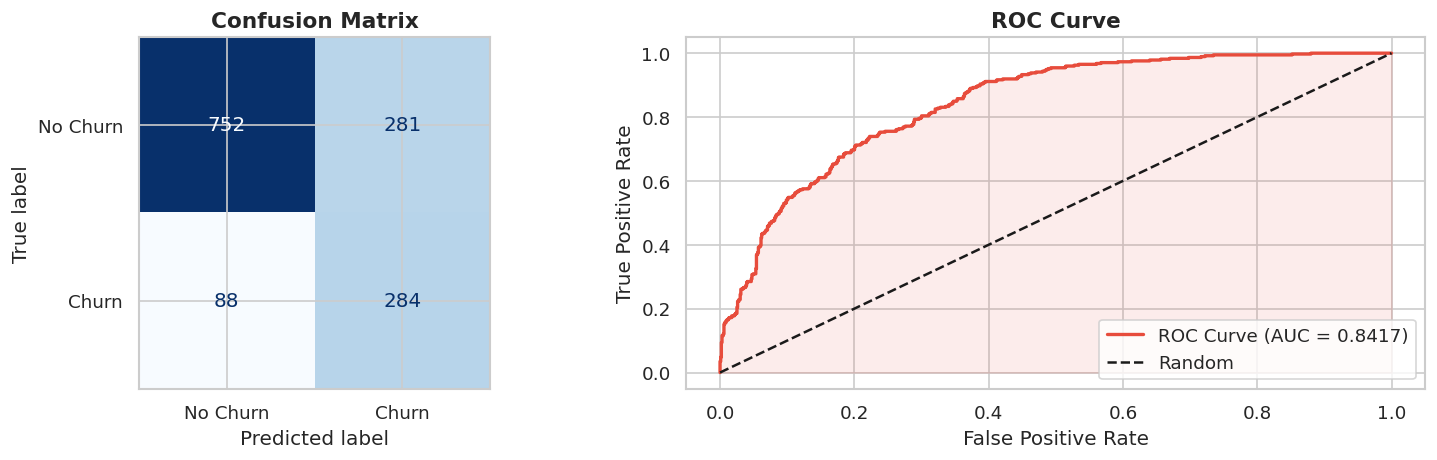

💾 Saved: 06_confusion_roc.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Churn', 'Churn'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13, fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'ROC Curve (AUC = {roc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('06_confusion_roc.png', bbox_inches='tight')
plt.show()
print("💾 Saved: 06_confusion_roc.png")

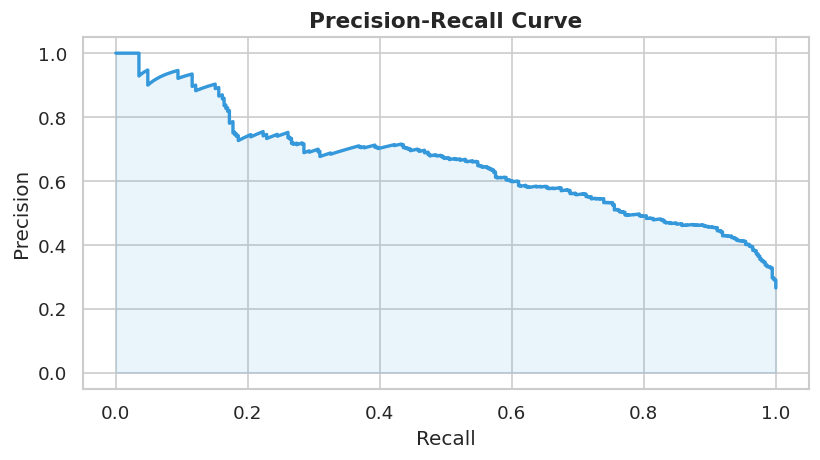

💾 Saved: 07_precision_recall.png


In [17]:
precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(recall, precision, color='#3498db', lw=2)
ax.fill_between(recall, precision, alpha=0.1, color='#3498db')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('07_precision_recall.png', bbox_inches='tight')
plt.show()
print("💾 Saved: 07_precision_recall.png")

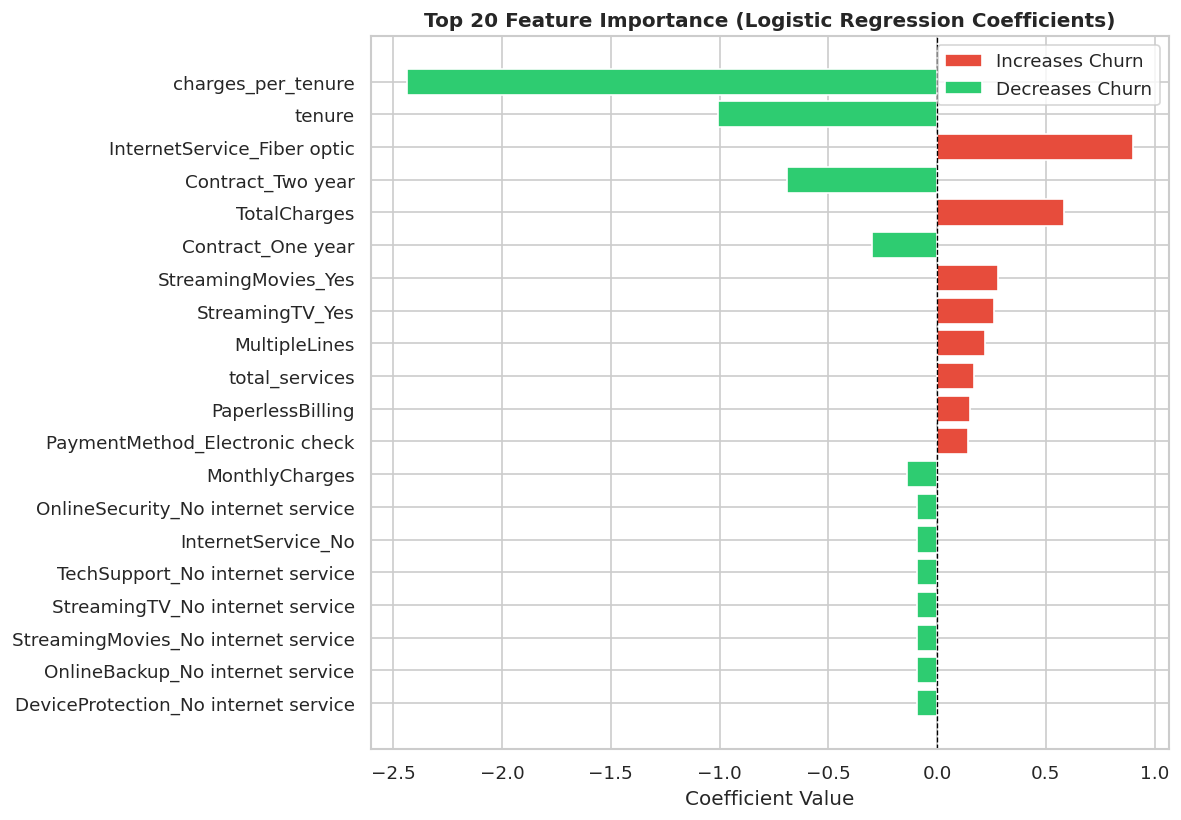

💾 Saved: 08_feature_importance.png


In [18]:
feature_names = X.columns.tolist()
coef = lr_model.coef_[0]

feat_imp = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': coef,
    'Abs_Coef'   : np.abs(coef)
}).sort_values('Abs_Coef', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if c > 0 else '#2ecc71'
          for c in feat_imp['Coefficient']]
bars = ax.barh(feat_imp['Feature'], feat_imp['Coefficient'],
               color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Top 20 Feature Importance (Logistic Regression Coefficients)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Coefficient Value')
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_el = [Patch(facecolor='#e74c3c', label='Increases Churn'),
             Patch(facecolor='#2ecc71', label='Decreases Churn')]
ax.legend(handles=legend_el)

plt.tight_layout()
plt.savefig('08_feature_importance.png', bbox_inches='tight')
plt.show()
print("💾 Saved: 08_feature_importance.png")

In [19]:
# Save model
joblib.dump(lr_model, 'logistic_regression_churn_model.pkl')
print("✅ Model saved  → logistic_regression_churn_model.pkl")

# Save scaler (IMPORTANT: same scaler needed for prediction)
joblib.dump(scaler, 'scaler_churn.pkl')
print("✅ Scaler saved → scaler_churn.pkl")

# Save feature names (for future prediction alignment)
feature_df = pd.DataFrame({'features': feature_names})
feature_df.to_csv('feature_names.csv', index=False)
print("✅ Feature list → feature_names.csv")

# ── Download in Google Colab ──────────────────────────────────
try:
    from google.colab import files
    files.download('logistic_regression_churn_model.pkl')
    files.download('scaler_churn.pkl')
    files.download('feature_names.csv')
    print("\n🎉 Files downloaded to your PC!")
except ImportError:
    print("\n📁 Not in Colab — files saved in current directory:")
    print(f"   → {os.path.abspath('logistic_regression_churn_model.pkl')}")
    print(f"   → {os.path.abspath('scaler_churn.pkl')}")
    print(f"   → {os.path.abspath('feature_names.csv')}")

✅ Model saved  → logistic_regression_churn_model.pkl
✅ Scaler saved → scaler_churn.pkl
✅ Feature list → feature_names.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 Files downloaded to your PC!


In [20]:
loaded_model  = joblib.load('logistic_regression_churn_model.pkl')
loaded_scaler = joblib.load('scaler_churn.pkl')

# Use test set as demo
sample       = X_test_sc[:5]
predictions  = loaded_model.predict(sample)
proba        = loaded_model.predict_proba(sample)[:, 1]

print("\n📊 Sample Predictions:")
print(f"{'#':<5} {'Prediction':<15} {'Churn Probability':>18}")
print("-" * 40)
for i, (pred, prob) in enumerate(zip(predictions, proba)):
    label = "⚠️ CHURN" if pred == 1 else "✅ NO CHURN"
    print(f"{i+1:<5} {label:<15} {prob*100:>16.2f}%")

print("\n✅ Model loaded and working perfectly!")


📊 Sample Predictions:
#     Prediction       Churn Probability
----------------------------------------
1     ⚠️ CHURN                   89.13%
2     ⚠️ CHURN                   78.43%
3     ⚠️ CHURN                   59.44%
4     ✅ NO CHURN                 14.10%
5     ✅ NO CHURN                  4.20%

✅ Model loaded and working perfectly!


In [21]:
print("\n" + "=" * 55)
print("🎯 FINAL SUMMARY")
print("=" * 55)
print(f"  Dataset Shape          : {df.shape}")
print(f"  Features Used          : {X.shape[1]}")
print(f"  Training Samples       : {X_train_sc.shape[0]}")
print(f"  Test Samples           : {X_test_sc.shape[0]}")
print(f"  Accuracy               : {acc*100:.2f}%")
print(f"  ROC-AUC Score          : {roc:.4f}")
print(f"  CV ROC-AUC (5-fold)    : {cv.mean():.4f} ± {cv.std():.4f}")
print("=" * 55)
print("📦 Saved Files:")
print("  🤖 logistic_regression_churn_model.pkl")
print("  📏 scaler_churn.pkl")
print("  📋 feature_names.csv")
print("  🖼️  01~08 PNG visualization files")
print("=" * 55)
print("✅ Pipeline Complete!")


🎯 FINAL SUMMARY
  Dataset Shape          : (7021, 20)
  Features Used          : 31
  Training Samples       : 5616
  Test Samples           : 1405
  Accuracy               : 73.74%
  ROC-AUC Score          : 0.8417
  CV ROC-AUC (5-fold)    : 0.8503 ± 0.0065
📦 Saved Files:
  🤖 logistic_regression_churn_model.pkl
  📏 scaler_churn.pkl
  📋 feature_names.csv
  🖼️  01~08 PNG visualization files
✅ Pipeline Complete!
